In [7]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

# 1. 加载训练数据
train_df = pd.read_csv('recommendation-ratings-train.txt')  # 替换为你的训练数据路径
test_df = pd.read_csv('recommendation-ratings-test.txt')    # 替换为你的测试数据路径

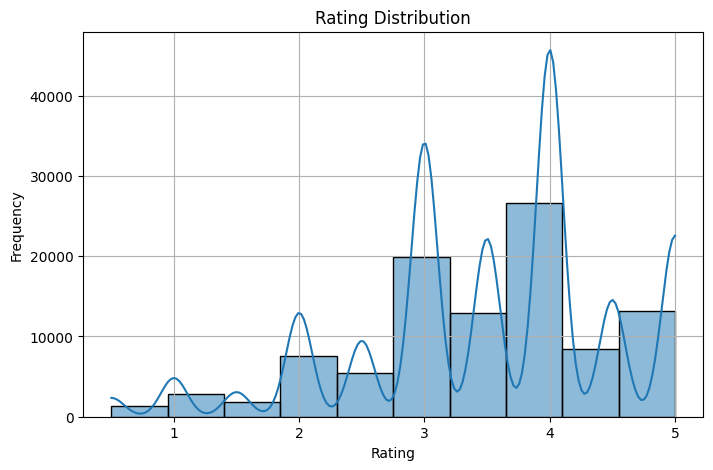

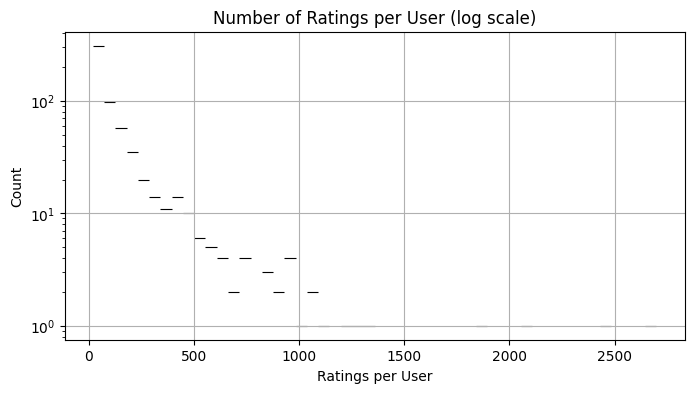

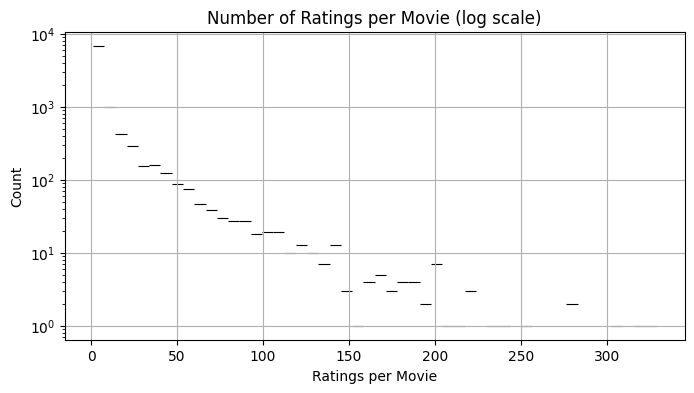

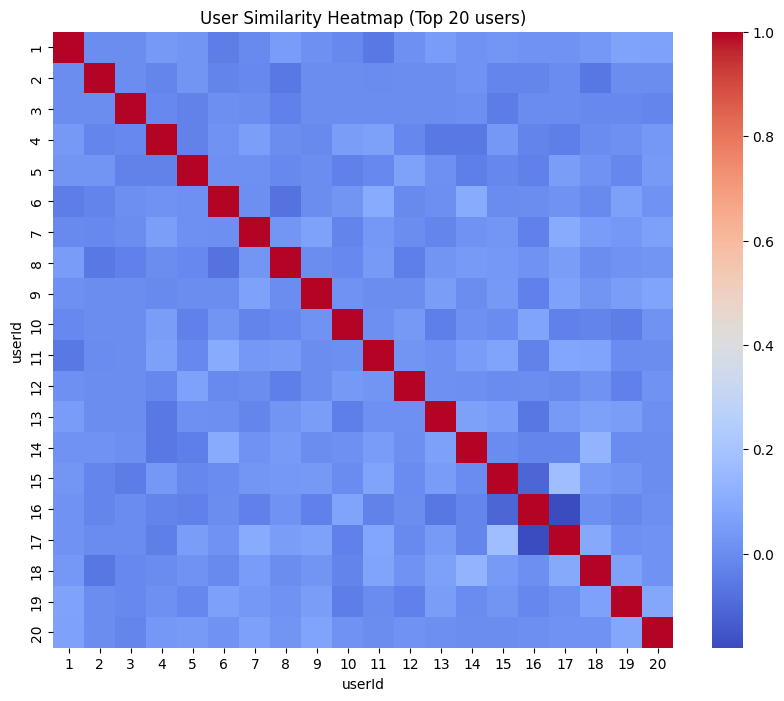

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 合并训练和测试集用于整体分布观察
combined_df = pd.concat([train_df, test_df])

# 评分分布
plt.figure(figsize=(8, 5))
sns.histplot(combined_df['rating'], bins=10, kde=True)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 每个用户评分数量分布
user_counts = train_df.groupby('userId').size()
plt.figure(figsize=(8, 4))
sns.histplot(user_counts, bins=50, log_scale=(False, True))
plt.title('Number of Ratings per User (log scale)')
plt.xlabel('Ratings per User')
plt.ylabel('Count')
plt.grid(True)
plt.show()

# 每部电影被评分的次数分布
movie_counts = train_df.groupby('movieId').size()
plt.figure(figsize=(8, 4))
sns.histplot(movie_counts, bins=50, log_scale=(False, True))
plt.title('Number of Ratings per Movie (log scale)')
plt.xlabel('Ratings per Movie')
plt.ylabel('Count')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 8))
subset = user_similarity_df.iloc[:20, :20]
sns.heatmap(subset, cmap='coolwarm', annot=False)
plt.title('User Similarity Heatmap (Top 20 users)')
plt.show()

In [11]:
# 2. 构建用户-电影评分矩阵（缺失项为NaN）
rating_matrix = train_df.pivot(index='userId', columns='movieId', values='rating')

# 3. 用户评分均值 + 去均值（中心化）
user_mean = rating_matrix.mean(axis=1)
rating_matrix_centered = rating_matrix.sub(user_mean, axis=0)
rating_matrix_centered = rating_matrix_centered.fillna(0)

# 计算用户相似度（使用中心化评分）
user_similarity = cosine_similarity(rating_matrix_centered)
user_similarity_df = pd.DataFrame(user_similarity, index=rating_matrix.index, columns=rating_matrix.index)

# 4. 优化后的预测函数：正相似度 + baseline（用户均值）
def predict_rating(target_user_id, target_movie_id, k=5):
    if target_movie_id in rating_matrix.columns:
        sims = user_similarity_df.loc[target_user_id]
        movie_ratings = rating_matrix[target_movie_id]
        valid_users = movie_ratings[movie_ratings.notna()].index

        sims = sims[valid_users]
        movie_ratings = movie_ratings[valid_users]

        # 保留正相似度的用户
        sims = sims[sims > 0]
        movie_ratings = movie_ratings[sims.index]

        if sims.empty:
            return None

        # 取相似度前k用户
        top_k_users = sims.sort_values(ascending=False).head(k)
        top_k_ratings = movie_ratings[top_k_users.index]

        # 加入 baseline 修正
        baseline = user_mean[target_user_id]
        top_k_means = user_mean[top_k_users.index]
        adjusted_ratings = top_k_ratings - top_k_means

        weighted_sum = (adjusted_ratings * top_k_users).sum()
        sim_sum = top_k_users.sum()

        if sim_sum == 0:
            return None
        return baseline + (weighted_sum / sim_sum)
    else:
        return None

# 5. 对测试集进行评分预测
predictions = []
for _, row in test_df.iterrows():
    user_id = row['userId']
    movie_id = row['movieId']
    true_rating = row['rating']
    pred_rating = predict_rating(user_id, movie_id, k=5)
    predictions.append((user_id, movie_id, true_rating, pred_rating))

# 6. 评估 RMSE
pred_df = pd.DataFrame(predictions, columns=['userId', 'movieId', 'true_rating', 'pred_rating'])
pred_df = pred_df.dropna()

rmse = np.sqrt(mean_squared_error(pred_df['true_rating'], pred_df['pred_rating']))
print(f'RMSE: {rmse:.4f}')

RMSE: 1.1236
